# COMSOL transmon capacitance and field

::::{admonition} Required extras
:class: tip

This notebook needs the `comsol` extra:

```bash
uv add "qpdk[comsol]"          # or: pip install "qpdk[comsol]"
uv sync --extra comsol         # from a checkout of this repository
```

Installing the extra installs `MPh`, the Python client for COMSOL, and nothing
else. **It does not install COMSOL and it does not grant a license.** Running
the model build and the electrostatic solve needs a local COMSOL installation
and a license. Google Colab has neither, so the build cells cannot run there.

See the {ref}`extras reference <notebook-extras>` for what each extra installs.
::::

This notebook extracts the two capacitor pads of a QPDK double-pad transmon,
builds a COMSOL sheet model around them, solves the electrostatic problem, and
reads back the pad capacitance and stored energy.

## How this page is published

The figures and numbers on this page are **saved cell outputs**. The numerical
data comes from licensed COMSOL solves; the plotting cells were rerun against
those exports and saved in the committed notebook. The documentation renders
that copy rather than running the cells again.

The whole path is scripted, so a licensed machine reproduces it end to end by
setting `RUN_COMSOL = True`. Without a license the notebook still runs from top
to bottom: the COMSOL cells are skipped, and every cell that reads results
prints how to supply them instead of plotting. On a fresh machine with neither
a license nor exported results you will therefore see the stored figures in the
documentation, but a local run prints skip messages rather than plots. To
replot locally, either export the files with `RUN_COMSOL = True`, or set
`RESULTS_DIR` to a directory that already holds an exported copy.

## What is being modelled

The device is a QPDK
{py:func}`~qpdk.cells.transmon.double_pad_transmon_with_bbox`: two rectangular
capacitor pads separated by a small gap, with a SQUID loop at the centre. The
pads dominate the total capacitance $C$, and the SQUID supplies the Josephson
energy $E_J$, so the qubit transition frequency is set by $E_J$ and the
charging energy $E_C = e^2 / 2C$ {cite:p}`kochChargeinsensitiveQubitDesign2007a`.

In the real device the pads are joined **only** through the Josephson
junction. The QPDK cell draws the SQUID's leads and contact patches on
`JJ_AREA` and `JJ_PATCH`, and those oxide barriers are not metal shorts. The
extraction here works on an **EM-only copy** with those two layers removed, so
the SQUID loop and its leads are not part of the solved geometry and their
parasitic inductance and capacitance are omitted. What remains is the two pads
and the surrounding ground plane, which is exactly what the pad capacitance
needs.

## What the solve is, and what it is not

The physics added is **Electrostatics**, not electromagnetic waves:

- The left pad is driven by a voltage terminal, and the right pad and the
  ground plane are held at ground.
- The solve returns `es.C11`, the capacitance of the driven pad to the grounded
  rest of the chip, and `es.intWe`, the stored electric energy. The two agree,
  since $2 W_e / V^2 = C_{11}$, the standard relation between the energy stored
  in the field and the capacitance of the conductors {cite:p}`m.pozarMicrowaveEngineering2012`.

This is a **quasi-static capacitance extraction**. It says nothing about a
resonance, because there is no resonant element in the model: no Josephson
inductance is present, and the metal is a perfect conductor.

The cells below run this pipeline, in this order:

::::{only} html
```{mermaid}
flowchart TB
    A["Transmon cell:<br>two pads with a SQUID loop"]
    B["EM-only copy:<br>JJ_AREA and JJ_PATCH removed"]
    C["Extracted layout:<br>two pad polygons and the ground plane"]
    D["Sheet model:<br>air above, silicon below, metal faces at z = 0"]
    E["Electrostatics:<br>voltage terminal on the left pad,<br>ground on the right pad and the chip ground"]
    F["Mesh and stationary study"]
    G["Results:<br>es.C11, es.intWe, and the V and es.normE export"]
    A --> B --> C --> D --> E --> F --> G
```
::::

::::{only} typst or typstpdf
The pipeline: the transmon cell, then an EM-only copy with `JJ_AREA` and
`JJ_PATCH` removed, then the extracted layout of two pad polygons and the
ground plane, then the sheet model with air above and silicon below, then an
Electrostatics interface with a voltage terminal on the left pad and ground on
the right pad and the chip ground, then the mesh and a stationary study, then
the capacitance, energy, and field results.
::::

### The LC frequency is an estimate, not an eigenmode

Given $C_{11}$ one can pick a Josephson inductance $L_J$ and form
$f_{LC} = 1 / (2 \pi \sqrt{L_J C_{11}})$. That number is an **estimate**: it uses
an inductance that is not in the COMSOL model, and it is neither a COMSOL
eigenfrequency nor the transmon $f_{01}$. A transmon is an anharmonic oscillator
whose spectrum follows from $E_J$ and $E_C$ treated as a quantum circuit, not
from a single linear LC resonance {cite:p}`blaisCircuitQuantumElectrodynamics2021`,
so the true $f_{01}$ also carries the $E_C$ anharmonic correction. QPDK's
scQubits notebook and {cite:p}`groszkowskiScqubitsPythonPackage2021` provide that
treatment. The value below is labelled an estimate wherever it appears.

::::{admonition} Reading the numbers on this page
:class: warning

The capacitance and energy come from the licensed electrostatic solves below,
but they are not a validated device prediction. The metal is a perfect
conductor, the SQUID loop and leads are absent, and $C_{11}$ is a one-terminal
value rather than the two-pad differential capacitance that sets $E_C$. The
plots and tables further down show how far the value moves with the fineness of
the mesh, with the size of the solved box, and with the air above and the
silicon below the metal. Over the last tested mesh refinement at the chosen
8000 µm / 1600 µm / 1600 µm box the one-terminal $C_{11}$ is stable to about
0.05%, but that is an empirical last-step figure and not a rigorous error bound.
::::

**References:**
- QPDK transmon physics and the double-pad cell: {py:func}`~qpdk.cells.transmon.double_pad_transmon_with_bbox`
- [COMSOL Electrostatics interface](https://doc.comsol.com/6.3/doc/com.comsol.help.acdc/acdc_ug_electric_fields.07.002.html)
- [COMSOL capacitance example](https://doc.comsol.com/6.3/doc/com.comsol.help.models.acdc.capacitor_dc/capacitor_dc.html)
- [COMSOL Reference Manual: Analyzing Model Convergence and Accuracy](https://doc.comsol.com/6.3/doc/com.comsol.help.comsol/comsol_ref_modeling.19.043.html)
- [MPh tutorial](https://mph.readthedocs.io/en/stable/tutorial.html)

## Setup and imports

In [1]:
import sys

if "google.colab" in sys.modules:
    import subprocess

    print("Running in Google Colab. Installing QPDK...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "qpdk[comsol] @ git+https://github.com/gdsfactory/quantum-rf-pdk.git",
    ])
    print(
        "Note: this installs the Python client only. COMSOL itself and its "
        "license are not pip-installable, so the build and solve cells below "
        "cannot run in Colab, and the result cells will report that no exported "
        "results are present."
    )

In [2]:
import json
import math
from itertools import pairwise
from operator import itemgetter
from pathlib import Path
from typing import Any, NamedTuple

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
from matplotlib import axes as mpl_axes, font_manager
from matplotlib.colors import LogNorm
from matplotlib.patches import Polygon as MplPolygon

from qpdk import PDK
from qpdk.cells.transmon import double_pad_transmon_with_bbox
from qpdk.config import PATH
from qpdk.simulation import (
    add_qubit_capacitance_study,
    build_comsol_sheet_model,
    pin_absolute_mesh_sizes,
    prepare_comsol_layout,
)
from qpdk.tech import LAYER

try:
    import mph
except ImportError:
    mph = None

PDK.activate()

MPH_AVAILABLE = mph is not None


def _outfit_titles() -> None:
    """Draw plot titles in Outfit bold, matching the documentation headings."""
    original_set_title = mpl_axes.Axes.set_title

    def _set_title(self: mpl_axes.Axes, *args: Any, **kwargs: Any) -> Any:
        kwargs.setdefault("fontfamily", "Outfit")
        kwargs.setdefault("fontweight", "bold")
        return original_set_title(self, *args, **kwargs)

    mpl_axes.Axes.set_title = _set_title


def apply_qpdk_style() -> str:
    """Apply the QPDK plot style, falling back to matplotlib's own defaults.

    The style is ``docs/qpdk.mplstyle`` in a checkout and the installed ``qpdk``
    style in a documentation environment; a downloaded notebook outside both
    keeps matplotlib's defaults instead of failing. The documentation fonts are
    used when they are installed, and matplotlib's bundled families otherwise.

    Returns:
        A short description of the style that was applied.
    """
    for source in (PATH.repo / "docs" / "qpdk.mplstyle", "qpdk"):
        try:
            plt.style.use(source)
        except OSError:
            continue
        applied = str(source)
        break
    else:
        applied = "matplotlib defaults"

    installed = {font.name for font in font_manager.fontManager.ttflist}
    plt.rcParams["font.sans-serif"] = [
        name
        for name in ("Inter", "Outfit", "DejaVu Sans", "Helvetica", "Arial")
        if name in installed
    ] + ["sans-serif"]
    if "Outfit" in installed:
        _outfit_titles()
    return applied


def prefer_svg_figures() -> None:
    """Save every figure as SVG as well as PNG, so stored outputs stay vector.

    The saved cell outputs are what the documentation renders, and both the HTML
    and the Typst PDF build embed the SVG ahead of the PNG. The PNG is kept as a
    fallback for a viewer that cannot render SVG, and text is written as paths so
    the figures carry their own glyphs instead of relying on installed fonts.
    Outside a notebook kernel there is no inline backend to configure, so a
    plain script run keeps matplotlib's PNG default.
    """
    try:
        # Ships with ipykernel, so it is present in a notebook kernel only.
        from matplotlib_inline.backend_inline import (  # ruff: ignore[import-outside-top-level]
            set_matplotlib_formats,
        )
    except ImportError:
        return
    plt.rcParams["svg.fonttype"] = "path"
    set_matplotlib_formats("svg", "png")


def result_file(name: str) -> Path | None:
    """Return the path of an exported solver result, if one is available.

    Args:
        name: File name to look for inside ``RESULTS_DIR``.

    Returns:
        The path, or ``None`` when ``RESULTS_DIR`` is unset or holds no such file.
    """
    if RESULTS_DIR is None:
        return None
    path = RESULTS_DIR / name
    return path if path.exists() else None


def explain_missing_results(name: str) -> None:
    """Print how to supply a result file that is not on disk.

    Args:
        name: File name that was looked for inside ``RESULTS_DIR``.
    """
    print(
        f"No {name} in RESULTS_DIR ({RESULTS_DIR}). The figures on the "
        "documentation page are saved outputs of a licensed solve, and the cells "
        "here replot only from files on disk. To supply them, run with "
        "RUN_COMSOL = True on a licensed machine, which exports into MODEL_DIR, "
        "or set RESULTS_DIR to a directory that already holds an exported "
        f"{name}."
    )


prefer_svg_figures()
STYLE_SOURCE = apply_qpdk_style()
print("Plot style: QPDK" if STYLE_SOURCE != "matplotlib defaults" else STYLE_SOURCE)

Plot style: QPDK


## Build the transmon cell and an EM-only copy

`prepare_comsol_layout` rejects components carrying geometry on layers it does
not model, and the junction layers are among those. The simplification is made
explicit here: the cell is copied and `JJ_AREA` and `JJ_PATCH` are removed, so
only `M1_DRAW` and the `M1_ETCH` mask it is inverted from remain.

In [3]:
component = double_pad_transmon_with_bbox(bbox_extension=200.0)

junction_port = component.ports["junction"]
JUNCTION_CENTER_UM = tuple(junction_port.center)

em_component = component.copy()
em_component.remove_layers(layers=[LAYER.JJ_AREA, LAYER.JJ_PATCH])

print(f"Component: {component.name}")
print(f"Bounding box (µm): {component.bbox()}")
print(f"Junction site: center={JUNCTION_CENTER_UM} µm")
print(f"Layers kept:   {sorted(em_component.layers)}")
print("JJ_AREA/JJ_PATCH removed; M1_DRAW and M1_ETCH remain.")

Component: double_pad_transmon_with_bbox_BE200_PS250_400_PG15_JSsq_c3fdad3b
Bounding box (µm): (-457.5,-400;457.5,400)
Junction site: center=(0.0, 0.0) µm
Layers kept:   [(1, 0), (1, 1)]
JJ_AREA/JJ_PATCH removed; M1_DRAW and M1_ETCH remain.


## Extract the COMSOL layout

The qubit pads are not transmission-line ports, so the extraction is asked for
no feed ports. The etched moat is a *hole* in the ground-plane polygon; the two
pads sit inside it as separate metal polygons.

In [4]:
layout = prepare_comsol_layout(em_component, feed_ports=None, ground_margin=100.0)

print(f"Metal polygons: {len(layout.polygons)}")
print(f"Feed ports:     {layout.feed_ports}")
print(f"Prepared bbox (µm): {layout.bbox}")

# Three conductor faces: the two pads and the ground plane. Each point below
# sits well inside its metal region so the face selection resolves to exactly
# one face, which the study builder checks before adding the terminals.
LEFT_PAD_POINT = (-132.5, 0.0)
RIGHT_PAD_POINT = (132.5, 0.0)
GROUND_POINT = (-500.0, 0.0)

Metal polygons: 3
Feed ports:     ()
Prepared bbox (µm): ComsolBoundingBox(xmin=-557.5, ymin=-500.0, xmax=557.5, ymax=500.0)


findfont: Failed to find font weight bold, now using 400.


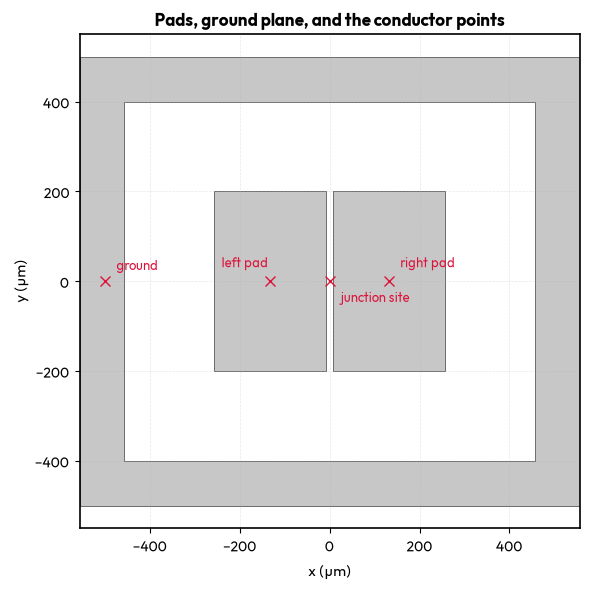

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))
for polygon in sorted(
    layout.polygons,
    key=lambda item: (
        -(
            (max(x for x, _ in item.outline) - min(x for x, _ in item.outline))
            * (max(y for _, y in item.outline) - min(y for _, y in item.outline))
        )
    ),
):
    ax.add_patch(
        MplPolygon(
            polygon.outline,
            closed=True,
            facecolor="0.78",
            edgecolor="0.35",
            linewidth=0.6,
            zorder=1,
        )
    )
    for hole in polygon.holes:
        ax.add_patch(
            MplPolygon(
                hole,
                closed=True,
                facecolor="white",
                edgecolor="0.35",
                linewidth=0.6,
                zorder=1,
            )
        )
for point, label, offset in (
    (LEFT_PAD_POINT, "left pad", (-35, 10)),
    (RIGHT_PAD_POINT, "right pad", (8, 10)),
    (GROUND_POINT, "ground", (8, 8)),
    (JUNCTION_CENTER_UM, "junction site", (8, -15)),
):
    ax.plot(*point, marker="x", color="crimson", markersize=7, zorder=4)
    ax.annotate(
        label,
        point,
        textcoords="offset points",
        xytext=offset,
        fontsize=9,
        color="crimson",
    )
ax.set_aspect("equal")
ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
ax.set_title("Pads, ground plane, and the conductor points")
plt.tight_layout()
plt.show()

## Build the COMSOL model and capacitance study

Three calls configure the model:

- {py:func}`~qpdk.simulation.comsol_sheet.build_comsol_sheet_model` creates the
  air and silicon blocks meeting at $z = 0$, imprints the layout metal on that
  interface as faces, and assigns materials ($\epsilon_r = 1$ air,
  $\epsilon_r = 11.7$ silicon).
- {py:func}`~qpdk.simulation.comsol_capacitance.add_qubit_capacitance_study`
  picks the two pad faces and the ground face with the points above, drives the
  left pad with a voltage terminal, grounds the right pad and the ground plane,
  and adds the mesh and a stationary study. The selection builder refuses a
  point that does not land on exactly one face, so a wrong point fails loudly
  instead of grounding the wrong area.
- {py:func}`~qpdk.simulation.comsol_mesh.pin_absolute_mesh_sizes` runs that
  mesh once and then replaces the sizing COMSOL derived from the physics with
  absolute element sizes in micrometres, on the whole model and on the two pads
  and the ground plane separately. A physics-controlled mesh scales its sizes
  with the longest dimension of the domain, so without this the near-metal
  resolution would move whenever the domain did. The domain series further down
  the page depends on the sizes staying put.

The main solve uses the base configuration the domain series further down also
starts from: 8000 µm of lateral margin, 1600 µm of silicon, 1600 µm of air, and
`MAIN_NEAR_METAL`, the finest `0.625/1.25` entry of `NEAR_METAL_SIZES`. Those
are the values of the constants below, and they are what the saved metrics
report and what the field map below shows.

`mph.start(cores=...)` launches a local COMSOL process and attaches to it.
Only one MPh client can exist per Python process, and the call needs a COMSOL
installation and a license. The block is off by default so the notebook runs
without one; set `RUN_COMSOL = True` on a licensed machine to build, solve, and
save the model.

`RUN_DOMAIN_STUDY` turns on the series further down this page. It builds and
solves one fresh model per case, with the element sizes pinned and one of the
lateral margin, the near-metal resolution, the substrate thickness, or the air
height moved away from the base case, so it needs `RUN_COMSOL = True` for the
client and costs a build, a mesh, and a solve per case. The cases with the
smallest near-metal elements are the expensive ones. It is off by default.

`RESULTS_DIR` is where the cells that read results look for exported files. It
defaults to `None` so that a run without a license skips those cells, and to
`MODEL_DIR` when `RUN_COMSOL` is `True`, because the licensed branch below
exports into `MODEL_DIR`. Point it at any directory of exported files to replot
an existing run without starting COMSOL, for example
`RESULTS_DIR = Path("exports")`.

In [6]:
RUN_COMSOL = False
RUN_DOMAIN_STUDY = False  # domain and near-metal mesh series below; needs RUN_COMSOL
MODEL_DIR = Path.home() / "comsol_models"
MODEL_PATH = MODEL_DIR / "comsol_qubit_capacitance.mph"
RESULTS_DIR: Path | None = MODEL_DIR if RUN_COMSOL else None
CORES = 4
VOLTAGE_V = 1.0

# The main solve's domain and element sizes, in µm. The domain series below reads
# these same values as its base, so the two sections describe one configuration.
AIR_HEIGHT_UM = 1600.0
SUBSTRATE_THICKNESS_UM = 1600.0
LATERAL_MARGIN_UM = 8000.0
# Element size COMSOL's physics-controlled build starts from. The pinned sizes
# below replace it, so it only sets the sizing the sequence is materialised with.
BASE_MESH_SIZE = 2
GLOBAL_HMAX_UM = 1000.0
GLOBAL_HMIN_UM = 2.0
HGRAD = 1.4
HCURVE = 0.5
HNARROW = 0.7
# One entry per near-metal resolution: (pad hmax, pad hmin, ground hmax,
# ground hmin) in µm, keyed by the pad and ground hmax. Every hmin is a tenth of
# its hmax, and the insertion order runs from the coarsest setting to the finest,
# which is the order the series is read in. The main solve uses MAIN_NEAR_METAL.
NEAR_METAL_SIZES = {
    "5/10": (5.0, 0.5, 10.0, 1.0),
    "2.5/5": (2.5, 0.25, 5.0, 0.5),
    "1.25/2.5": (1.25, 0.125, 2.5, 0.25),
    "0.8/1.6": (0.8, 0.08, 1.6, 0.16),
    "0.625/1.25": (0.625, 0.0625, 1.25, 0.125),
}
MAIN_NEAR_METAL = "0.625/1.25"

model = None
if RUN_COMSOL and not MPH_AVAILABLE:
    raise RuntimeError("RUN_COMSOL needs MPh and a licensed COMSOL installation")

if RUN_COMSOL and MPH_AVAILABLE:
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    client = mph.start(cores=CORES)
    (
        pad_hmax_um,
        pad_hmin_um,
        ground_hmax_um,
        ground_hmin_um,
    ) = NEAR_METAL_SIZES[MAIN_NEAR_METAL]
    model = build_comsol_sheet_model(
        client,
        layout,
        name="QPDK Double-Pad Transmon",
        substrate_thickness_um=SUBSTRATE_THICKNESS_UM,
        air_height_um=AIR_HEIGHT_UM,
        lateral_margin_um=LATERAL_MARGIN_UM,
    )
    add_qubit_capacitance_study(
        model,
        layout,
        left_pad_point=LEFT_PAD_POINT,
        right_pad_point=RIGHT_PAD_POINT,
        ground_point=GROUND_POINT,
        voltage_v=VOLTAGE_V,
        mesh_size=BASE_MESH_SIZE,
    )
    element_count = pin_absolute_mesh_sizes(
        model,
        global_hmax_um=GLOBAL_HMAX_UM,
        global_hmin_um=GLOBAL_HMIN_UM,
        pad_hmax_um=pad_hmax_um,
        pad_hmin_um=pad_hmin_um,
        ground_hmax_um=ground_hmax_um,
        ground_hmin_um=ground_hmin_um,
        hgrad=HGRAD,
        hcurve=HCURVE,
        hnarrow=HNARROW,
    )
    model.java.study("std1").run()
    for problem in model.problems():
        print(f"The main solve reports: {problem}")
    model.save(MODEL_PATH)

    capacitance_f = float(model.evaluate("es.C11"))
    stored_energy_j = float(model.evaluate("es.intWe"))
    print(f"es.C11 = {capacitance_f:.6e} F")
    print(f"es.intWe = {stored_energy_j:.6e} J")
    print(f"2*intWe/V^2 = {2.0 * stored_energy_j / VOLTAGE_V**2:.6e} F")
    print(f"Mesh elements = {element_count}")
    print(f"Saved model to {MODEL_PATH}")

    metrics_path = MODEL_DIR / "comsol_qubit_metrics.json"
    metrics_path.write_text(
        json.dumps(
            {
                "capacitance_f": capacitance_f,
                "stored_energy_j": stored_energy_j,
                "voltage_v": VOLTAGE_V,
                "solver": "COMSOL Multiphysics",
                "study": "Electrostatics stationary",
                "mesh": "absolute element sizes, physics-controlled sizing replaced",
                "base_mesh_size": BASE_MESH_SIZE,
                "element_count": element_count,
                "global_hmax_um": GLOBAL_HMAX_UM,
                "global_hmin_um": GLOBAL_HMIN_UM,
                "hgrad": HGRAD,
                "hcurve": HCURVE,
                "hnarrow": HNARROW,
                "near_metal": MAIN_NEAR_METAL,
                "pad_hmax_um": pad_hmax_um,
                "pad_hmin_um": pad_hmin_um,
                "ground_hmax_um": ground_hmax_um,
                "ground_hmin_um": ground_hmin_um,
                "lateral_margin_um": LATERAL_MARGIN_UM,
                "substrate_thickness_um": SUBSTRATE_THICKNESS_UM,
                "air_height_um": AIR_HEIGHT_UM,
                "silicon_relative_permittivity": 11.7,
            },
            indent=2,
        )
        + "\n"
    )

### Exporting the potential and field map

The potential and field map shown further down this page was written from the
main solved model above, on the main solve's domain with the near-metal element
sizes pinned, with COMSOL's Data export on a cut plane at $z = 1$ µm, carrying
the potential $V$ and the field norm `es.normE`. The same export is scripted
below: a `CutPlane` dataset over the $xy$ plane, then a `Data` result export
listing both expressions. It runs inside the licensed branch, next to the
solve, and writes into `MODEL_DIR`, where `RESULTS_DIR` picks it up.

In [7]:
if RUN_COMSOL and MPH_AVAILABLE and model is not None:
    plane = model.java.result().dataset().create("cutplane", "CutPlane")
    plane.set("planetype", "quick")
    plane.set("quickplane", "xy")
    plane.set("quickz", "1[um]")
    plane.set("data", "dset1")

    field_export = model.java.result().export().create("field", "Data")
    field_export.set("data", "cutplane")
    field_export.set("expr", ["V", "es.normE"])
    field_export.set("filename", str(MODEL_DIR / "comsol_qubit_field.txt"))
    field_export.run()
    print(f"Exported V and es.normE to {MODEL_DIR / 'comsol_qubit_field.txt'}")

## Saved capacitance result

This cell replots the exported metrics from the electrostatic solve above.
`C11` is the capacitance of the driven pad to the grounded rest of the chip,
and the stored energy is checked against it through $2 W_e / V^2$. This
one-terminal $C_{11}$ does not by itself give the differential-mode capacitance
of the two floating pads, so it is not yet the transmon charging capacitance.

The settings printed below are the ones the main solve actually used: 8000 µm of
lateral margin, 1600 µm of silicon and 1600 µm of air, and the absolute element
sizes that replaced COMSOL's physics-controlled sizing. They matter because
$C_{11}$ moves with both, and the series further down the page is what shows by
how much.

With `RESULTS_DIR` unset, or set to a directory without the export, the cell
prints how to supply the file instead of a result.

In [8]:
METRICS_JSON = "comsol_qubit_metrics.json"
metrics_file = result_file(METRICS_JSON)

capacitance_f: float | None = None
stored_energy_j: float | None = None
voltage_v: float | None = None

if metrics_file is None:
    explain_missing_results(METRICS_JSON)
else:
    metrics = json.loads(metrics_file.read_text())
    capacitance_f = float(metrics["capacitance_f"])
    stored_energy_j = float(metrics["stored_energy_j"])
    voltage_v = float(metrics["voltage_v"])

    capacitance_from_energy_f = 2.0 * stored_energy_j / voltage_v**2
    print(f"es.C11                       = {capacitance_f:.6e} F")
    print(f"2 * es.intWe / V^2           = {capacitance_from_energy_f:.6e} F")
    print(
        "relative difference          = "
        f"{abs(capacitance_from_energy_f - capacitance_f) / capacitance_f:.2e}"
    )
    for key in (
        "solver",
        "study",
        "mesh",
        "base_mesh_size",
        "near_metal",
        "element_count",
        "global_hmax_um",
        "global_hmin_um",
        "hgrad",
        "hcurve",
        "hnarrow",
        "pad_hmax_um",
        "pad_hmin_um",
        "ground_hmax_um",
        "ground_hmin_um",
        "lateral_margin_um",
        "substrate_thickness_um",
        "air_height_um",
    ):
        if (value := metrics.get(key)) is not None:
            print(f"{key:<28} = {value}")

es.C11                       = 1.253797e-13 F
2 * es.intWe / V^2           = 1.253797e-13 F
relative difference          = 5.64e-15
solver                       = COMSOL Multiphysics
study                        = Electrostatics stationary
mesh                         = absolute element sizes, physics-controlled sizing replaced
base_mesh_size               = 2
near_metal                   = 0.625/1.25
element_count                = 30893436
global_hmax_um               = 1000.0
global_hmin_um               = 2.0
hgrad                        = 1.4
hcurve                       = 0.5
hnarrow                      = 0.7
pad_hmax_um                  = 0.625
pad_hmin_um                  = 0.0625
ground_hmax_um               = 1.25
ground_hmin_um               = 0.125
lateral_margin_um            = 8000.0
substrate_thickness_um       = 1600.0
air_height_um                = 1600.0


### An LC frequency estimate

With $C_{11}$ in hand, a Josephson inductance $L_J$ gives a rough scale for the
circuit frequency. **$L_J$ is not part of the COMSOL solve**, and $C_{11}$ is
not the two-pad differential capacitance. The resulting number only shows the
scale one would get from these illustrative circuit values; it is not an
eigenfrequency or the transmon $f_{01}$.

In [9]:
LJ_H = 10e-9  # chosen, not solved for

if capacitance_f is None:
    print(f"Skipping the estimate: no {METRICS_JSON} available (see the note above).")
else:
    f_lc_ghz = 1.0 / (2.0 * np.pi * np.sqrt(LJ_H * capacitance_f)) / 1e9
    print(f"Chosen L_J                    = {LJ_H * 1e9:.1f} nH")
    print(f"illustrative f_LC using C11     = {f_lc_ghz:.3f} GHz")
    print("L_J is not in the model; C11 is not the differential pad capacitance.")

Chosen L_J                    = 10.0 nH
illustrative f_LC using C11     = 4.495 GHz
L_J is not in the model; C11 is not the differential pad capacitance.


## Saved potential and field map

The exported field is the potential $V$ and the electric-field norm on the
$z = 1$ µm plane. The metal sheet lies at $z = 0$ and the plane sits just above
it, so the map shows the potential holding across the driven pad and the field
concentrating in the pad gap and along the pad edges. This map is from the main
solve: the 8000 µm margin domain with the near-metal element sizes pinned to
absolute values.

The exported plane spans that whole domain, out to ±8.5 mm, and on that
scale the 250 x 400 µm pads and their 15 µm gap are a dot. The map below is
therefore a **close-up**: `FIELD_LIMIT_X_UM` and `FIELD_LIMIT_Y_UM` frame both
pads and the gap between them, and the points outside that window are dropped
before anything is drawn. The rest of the window is the etched moat around the
pads; the grounded conductor is a frame further out, from ±457.5 µm in $x$ and
±400 µm in $y$ to the edge of the prepared layout, so it lies outside this
close-up.

The remaining nodes are resampled onto a regular display grid to draw the map.
That resampling is **display only**: it reads the solved field, it does not
re-solve, re-mesh, or smooth it. The grid step is about 2 µm, coarser than the
finest pinned near-metal size, so the map is drawn at display resolution rather
than at the mesh's, with the pad gap and the pad edges still several cells wide.
Contouring the crop's nodes directly would draw the same picture from an SVG
many megabytes larger, because the plot is saved as vector art.

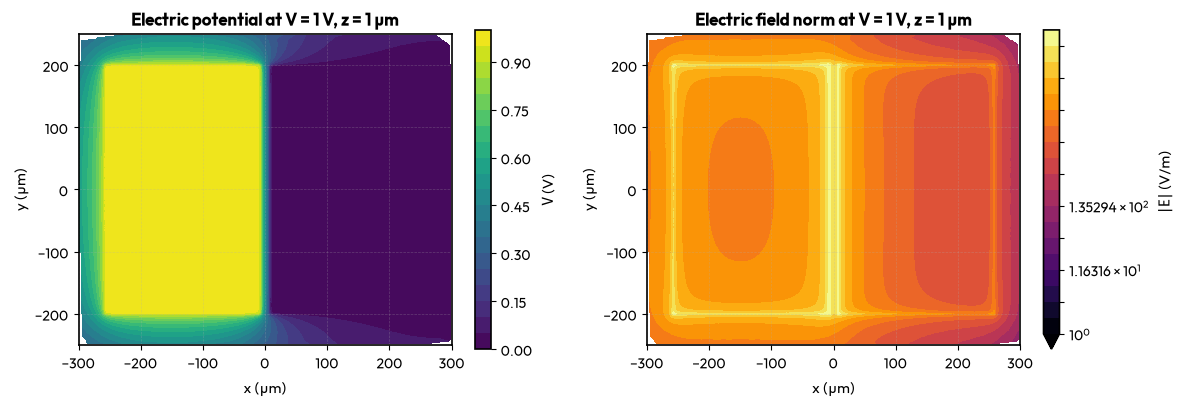

In [10]:
FIELD_TXT = "comsol_qubit_field.txt"
FIELD_LIMIT_X_UM = 300.0
FIELD_LIMIT_Y_UM = 250.0
FIELD_GRID_X = 300
FIELD_GRID_Y = 250
FIELD_LEVELS = 20

field_file = result_file(FIELD_TXT)

if field_file is None:
    explain_missing_results(FIELD_TXT)
else:
    field = np.loadtxt(field_file, comments="%")
    field_x, field_y = field[:, 0], field[:, 1]
    in_view = (np.abs(field_x) <= FIELD_LIMIT_X_UM) & (
        np.abs(field_y) <= FIELD_LIMIT_Y_UM
    )
    if in_view.sum() < 3:
        raise ValueError(
            f"No field nodes lie within ±{FIELD_LIMIT_X_UM:g} by "
            f"±{FIELD_LIMIT_Y_UM:g} µm, so there is nothing to draw a close-up from"
        )
    triangulation = mtri.Triangulation(field_x[in_view], field_y[in_view])
    grid_x = np.linspace(-FIELD_LIMIT_X_UM, FIELD_LIMIT_X_UM, FIELD_GRID_X)
    grid_y = np.linspace(-FIELD_LIMIT_Y_UM, FIELD_LIMIT_Y_UM, FIELD_GRID_Y)
    grid_xx, grid_yy = np.meshgrid(grid_x, grid_y)
    field_v = mtri.LinearTriInterpolator(triangulation, field[in_view, 3])(
        grid_xx, grid_yy
    ).filled(np.nan)
    field_e = mtri.LinearTriInterpolator(triangulation, field[in_view, 4])(
        grid_xx, grid_yy
    ).filled(np.nan)
    field_e_max = float(np.nanmax(field_e))

    voltage_label = f"at V = {voltage_v:g} V, " if voltage_v is not None else ""

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    potential = axes[0].contourf(
        grid_x, grid_y, field_v, levels=FIELD_LEVELS, cmap="viridis"
    )
    axes[0].set_title(f"Electric potential {voltage_label}z = 1 µm")
    fig.colorbar(potential, ax=axes[0], label=r"$V$ (V)")

    norm_e = axes[1].contourf(
        grid_x,
        grid_y,
        field_e,
        levels=np.geomspace(1.0, field_e_max, FIELD_LEVELS),
        norm=LogNorm(vmin=1.0, vmax=field_e_max),
        cmap="inferno",
        extend="min",
    )
    axes[1].set_title(f"Electric field norm {voltage_label}z = 1 µm")
    fig.colorbar(norm_e, ax=axes[1], label=r"$|\mathbf{E}|$ (V/m)")

    for axis in axes:
        axis.set_aspect("equal")
        axis.set_xlabel("x (µm)")
        axis.set_ylabel("y (µm)")
    plt.tight_layout()
    plt.show()

The potential is near its terminal value over the driven pad and falls to zero
across the gap to the grounded pad. Over the etched moat beyond the pads it sits
between the two, with no metal there to hold it at either. The field is
concentrated in that gap and at the pad edges, which is where the pad
capacitance mainly lives, and it is why the mesh has to resolve the gap and the
metal edges for the capacitance to converge. The close-up is what makes that gap
visible at all; on the full ±8.5 mm window of the export it would be a single
line.

## Domain and near-metal mesh study

COMSOL's physics-controlled mesh sizes scale with the longest dimension of the
domain. A series that changes the domain therefore changes the near-metal
resolution with it, and nothing read off such a series can separate the two.
Every case below pins the element sizes to absolute values in micrometres
instead, so the domain can move while the mesh stays where it was put. The main
solve above is built the same way, so its number and the rows here are
comparable.

### Two questions, one set of cases

1. **How much of $C_{11}$ comes from the finite box the model is solved in?**
   The model is not an open problem. The sheet model surrounds the metal with
   two finite blocks, air above and silicon below, both spanning the prepared
   layout box grown by `lateral_margin_um`. Their outer walls carry no explicit
   boundary condition, so they take the Electrostatics default for an exterior
   boundary, zero charge ($\mathbf{n} \cdot \mathbf{D} = 0$), and the ground
   plane itself reaches only 100 µm past the device bounding box. Field that
   would have spread out into a larger chip is turned back at a wall, and
   $C_{11}$ carries the signature of where that wall sits. The box is finite in
   all three directions, so the lateral margin is one of three lengths here:
   the air above the metal and the silicon below it are the other two.
2. **How much of it comes from the near-metal element size?** The capacitance
   of a pad to the grounded rest of the chip lives in the field at the pad gap
   and the pad edges, so the element size on the pads and on the ground plane
   beside them sets how well that field is resolved.

A mesh study alone cannot see the first effect, because refining elements does
not move a wall. A margin sweep alone cannot see the second one cleanly unless
the element sizes are pinned, and a margin sweep on its own cannot see what the
air above the metal contributes either. The cases below do all of it in one
series: the margin moves with the near-metal size held fixed, the near-metal
size changes at margins that have already been solved, and the air height and
the substrate thickness move away from the base case, so the levers can be read
against each other.

### How the sizes are pinned

Every case calls
{py:func}`~qpdk.simulation.comsol_mesh.pin_absolute_mesh_sizes`, which runs the
physics-controlled build once to materialise the mesh sequence and then writes
absolute sizes into it: `GLOBAL_HMAX_UM` and `GLOBAL_HMIN_UM` for the bulk air
and silicon away from the metal, and one size per conductor on the two pad
faces and the ground face. The sequence is left user-controlled, so a later
build cannot re-derive the sizing from the domain. The growth rate `HGRAD`, the
curvature resolution `HCURVE`, and the narrow-region resolution `HNARROW` are
pinned with the sizes, so they do not move either.

The near-metal sizes come in five settings, `NEAR_METAL_SIZES`, keyed by the pad
and ground `hmax`: `5/10` puts 5 µm elements on the pads and 10 µm on the ground
plane, `2.5/5` scales both by the same factor, and the settings run on down to
`0.625/1.25`. Every `hmin` is a tenth of its `hmax`. None of the five is a
converged mesh, and none is meant to be: what the series measures is the step
from each setting to the next smaller one, at element counts a licensed
workstation can still solve, and the finest settings are the slow ones.

### The cases

Every case is one fresh model, solved from scratch and removed from the client
afterwards, so nothing carries over from another case. Each one keeps the
layout, the three conductor points, the 1 V terminal, the electrostatics, and
the base mesh size the helper starts from; the case itself sets the lateral
margin, the substrate thickness, the air height, and the near-metal setting.

1. **Lateral margin** at the `5/10` near-metal sizes, for 2400, 8000, and
   16000 µm, and at the `2.5/5` and `1.25/2.5` sizes for 8000 and 16000 µm.
   Plotted as $C_{11}$ against the margin.
2. **Near-metal size** at 8000 and 16000 µm of margin for `5/10`, `2.5/5`, and
   `1.25/2.5`, and at 8000 µm of margin with 1600 µm of air for the four
   settings from `2.5/5` down to `0.625/1.25`. Plotted as $C_{11}$ against the
   mesh element count, and printed as the step from each setting to the next
   smaller one.
3. **Air height and substrate thickness** at 8000 µm of margin and the `2.5/5`
   near-metal sizes: the air from 200 µm up to 3200 µm over 1600 µm of silicon,
   and the silicon from 1600 µm up to 3200 µm under 200 µm of air. Each series
   is printed against its own shortest row, and the value the rest of the
   geometry was held at is printed in the table title.

The base case is the main solve's own configuration: 8000 µm of margin, 1600 µm
of silicon, and 1600 µm of air. The air ladder is read around that row, and the
substrate pair was solved under a shorter air column, so it forms a series of
its own rather than joining the base air group.

The rows on disk are completed licensed solves, so every case of the series has
landed. The convergence reading is still the deltas printed for those rows
rather than a statement made here.

### What these cases show, and what they do not

The tables below carry one set of deltas per series, and those deltas are the
reading: how far $C_{11}$ moves across the margins at a fixed mesh, from each
near-metal setting to the next finer one at a fixed domain, and from one air
height or substrate thickness to the next.

Two things follow from the shape of the series rather than from any single row.
The margin series on its own cannot see what the air above the metal
contributes, because no margin case moves it, so a domain claim read off the
margins alone would miss it. And a value that is still moving with the near-metal
size or with the air height has not converged, whatever the margin does; the
deltas the tables print are where that is read off, and they are what shows the
finest near-metal step at this box has become small.

A settled set of series is still not the transmon charging capacitance:
$C_{11}$ is the capacitance of the driven pad to the grounded rest of the chip,
not the differential capacitance of the two floating pads, and the SQUID and
its leads are missing from the geometry. It also says nothing about the peak
field at the metal edges, which stays mesh-limited at any domain size.

The series is off by default. Set `RUN_DOMAIN_STUDY = True` alongside
`RUN_COMSOL = True`; it reuses the client the licensed branch already started,
because only one MPh client can exist per Python process. It costs a build, a
mesh, and a solve per case. A case that fails to build, mesh, or solve is
printed in full and left out of the rows, and the failed cases stay in the JSON
next to the rows that were written, so a gap is visible rather than silently
dropped. The JSON is rewritten after every case, so interrupting a long series
keeps the cases already solved.

In [11]:
DOMAIN_JSON = "comsol_qubit_domain_convergence.json"


def write_json_atomically(path: Path, payload: dict[str, Any]) -> None:
    """Write JSON through a sibling temporary file, then replace in place.

    The series writes on every case, so an interrupt partway through still
    leaves the cases already solved on disk. The temporary file is a sibling so
    the replace stays a same-filesystem rename, which is what makes it atomic.

    Args:
        path: The JSON file to write.
        payload: The object to serialise.
    """
    temporary = path.with_name(path.name + ".tmp")
    temporary.write_text(json.dumps(payload, indent=2) + "\n")
    temporary.replace(path)


class DomainCase(NamedTuple):
    """One case of the domain and near-metal series.

    Attributes:
        lateral_margin_um: Margin around the layout box, in µm.
        substrate_thickness_um: Silicon thickness below the interface, in µm.
        air_height_um: Air height above the interface, in µm.
        near_metal: Key of a near-metal element size setting in
            ``NEAR_METAL_SIZES``.
    """

    lateral_margin_um: float
    substrate_thickness_um: float
    air_height_um: float
    near_metal: str


def domain_case_label(case: DomainCase) -> str:
    """Name every case parameter on a single line.

    Args:
        case: One case of the series.

    Returns:
        A label holding the margin, the substrate thickness, the air height, and
        the near-metal setting, so cases sharing a margin and a setting but not
        an air height stay apart.
    """
    return (
        f"margin {case.lateral_margin_um:g} µm, "
        f"substrate {case.substrate_thickness_um:g} µm, "
        f"air {case.air_height_um:g} µm, {case.near_metal} near-metal sizes"
    )


# (lateral margin µm, substrate µm, air µm, near-metal setting). The margin is
# swept at a fixed near-metal setting, the near-metal setting at margins that have
# already been solved and at air the base case does not use, and the substrate
# thickness and air height away from the base case, so every lever can be read
# against the others.
DOMAIN_CASES = (
    DomainCase(2400.0, 1600.0, 200.0, "5/10"),
    DomainCase(8000.0, 1600.0, 200.0, "5/10"),
    DomainCase(16000.0, 1600.0, 200.0, "5/10"),
    DomainCase(8000.0, 1600.0, 200.0, "2.5/5"),
    DomainCase(16000.0, 1600.0, 200.0, "2.5/5"),
    DomainCase(8000.0, 1600.0, 200.0, "1.25/2.5"),
    DomainCase(16000.0, 1600.0, 200.0, "1.25/2.5"),
    DomainCase(8000.0, 1600.0, 400.0, "2.5/5"),
    DomainCase(8000.0, 1600.0, 800.0, "2.5/5"),
    DomainCase(8000.0, 3200.0, 200.0, "2.5/5"),
    DomainCase(8000.0, 1600.0, 1600.0, "2.5/5"),
    DomainCase(8000.0, 1600.0, 3200.0, "2.5/5"),
    DomainCase(16000.0, 1600.0, 1600.0, "2.5/5"),
    DomainCase(8000.0, 1600.0, 1600.0, "1.25/2.5"),
    DomainCase(8000.0, 1600.0, 1600.0, "0.8/1.6"),
    DomainCase(8000.0, 1600.0, 1600.0, "0.625/1.25"),
)


def run_qubit_domain_case(client: Any, case: DomainCase) -> dict[str, Any]:
    """Build, mesh, and solve one domain case, and return its row.

    The model is built from scratch on the substrate thickness and air height the
    case sets, with the base mesh size the main solve uses, and the mesh is then
    pinned to absolute element sizes, so only the case parameters differ between
    cases. The model is removed from the client even when the build, the mesh, or
    the solve raises.

    Args:
        client: The MPh client the licensed branch already started.
        case: Lateral margin, substrate thickness, air height, and the near-metal
            setting name.

    Returns:
        A row holding the case parameters, the element sizes that were pinned,
        the mesh element count, ``es.C11`` in farads, and ``es.intWe`` in joules
        at ``VOLTAGE_V``.
    """
    pad_hmax_um, pad_hmin_um, ground_hmax_um, ground_hmin_um = NEAR_METAL_SIZES[
        case.near_metal
    ]
    temp_model = build_comsol_sheet_model(
        client,
        layout,
        name=f"QPDK transmon domain {domain_case_label(case)}",
        substrate_thickness_um=case.substrate_thickness_um,
        air_height_um=case.air_height_um,
        lateral_margin_um=case.lateral_margin_um,
    )
    try:
        add_qubit_capacitance_study(
            temp_model,
            layout,
            left_pad_point=LEFT_PAD_POINT,
            right_pad_point=RIGHT_PAD_POINT,
            ground_point=GROUND_POINT,
            voltage_v=VOLTAGE_V,
            mesh_size=BASE_MESH_SIZE,
        )
        element_count = pin_absolute_mesh_sizes(
            temp_model,
            global_hmax_um=GLOBAL_HMAX_UM,
            global_hmin_um=GLOBAL_HMIN_UM,
            pad_hmax_um=pad_hmax_um,
            pad_hmin_um=pad_hmin_um,
            ground_hmax_um=ground_hmax_um,
            ground_hmin_um=ground_hmin_um,
            hgrad=HGRAD,
            hcurve=HCURVE,
            hnarrow=HNARROW,
        )
        temp_model.java.study("std1").run()
        for problem in temp_model.problems():
            print(f"  {domain_case_label(case)} reports: {problem}")
        return {
            "lateral_margin_um": case.lateral_margin_um,
            "substrate_thickness_um": case.substrate_thickness_um,
            "air_height_um": case.air_height_um,
            "near_metal": case.near_metal,
            "pad_hmax_um": pad_hmax_um,
            "pad_hmin_um": pad_hmin_um,
            "ground_hmax_um": ground_hmax_um,
            "ground_hmin_um": ground_hmin_um,
            "global_hmax_um": GLOBAL_HMAX_UM,
            "global_hmin_um": GLOBAL_HMIN_UM,
            "hgrad": HGRAD,
            "hcurve": HCURVE,
            "hnarrow": HNARROW,
            "base_mesh_size": BASE_MESH_SIZE,
            "voltage_v": VOLTAGE_V,
            "element_count": element_count,
            "c11_f": float(np.atleast_1d(temp_model.evaluate("es.C11"))[0]),
            "int_we_j": float(np.atleast_1d(temp_model.evaluate("es.intWe"))[0]),
        }
    finally:
        client.remove(temp_model)


if RUN_COMSOL and MPH_AVAILABLE and RUN_DOMAIN_STUDY:
    domain_rows: list[dict[str, Any]] = []
    domain_failures: list[dict[str, Any]] = []
    domain_path = MODEL_DIR / DOMAIN_JSON

    def save_domain() -> None:
        """Write the cases solved so far, so a late failure keeps them."""
        domain_payload: dict[str, Any] = {"rows": domain_rows}
        if domain_failures:
            domain_payload["failures"] = domain_failures
        write_json_atomically(domain_path, domain_payload)

    save_domain()
    for case in DOMAIN_CASES:
        print(f"{domain_case_label(case)}: building, meshing, and solving")
        try:
            row = run_qubit_domain_case(client, case)
        except Exception as error:
            domain_failures.append({
                "label": domain_case_label(case),
                "error": type(error).__name__,
            })
            print(f"{domain_case_label(case)} FAILED: {type(error).__name__}: {error}")
            save_domain()
            continue
        domain_rows.append(row)
        print(
            f"{domain_case_label(case)}: {row['element_count']} elements, "
            f"C11 = {row['c11_f'] * 1e15:.4f} fF, "
            f"intWe = {row['int_we_j']:.6e} J"
        )
        save_domain()

    print(f"Wrote {len(domain_rows)} of {len(DOMAIN_CASES)} rows to {domain_path}")
    if domain_failures:
        failed = ", ".join(item["label"] for item in domain_failures)
        print(f"No row was written for: {failed}")
elif RUN_DOMAIN_STUDY and not RUN_COMSOL:
    print(
        "RUN_DOMAIN_STUDY needs RUN_COMSOL = True: the series reuses the COMSOL "
        "client that the licensed branch starts."
    )

### Reading the domain and mesh series

The cell below draws two views of the rows solved at the base substrate
thickness and air height. Most of the cases at that air height walk the
near-metal ladder at one margin, so the margin view carries few points and the
mesh view is the denser one; either way the tables below print the deltas for
whichever rows are on disk:

- $C_{11}$ in fF against the lateral margin, one line per near-metal setting,
  each point labelled with its element count. A line that flattens says the
  outer walls no longer set $C_{11}$ at that mesh.
- $C_{11}$ in fF against the mesh element count, one line per margin, each
  point labelled with its near-metal setting. A line that flattens as the
  elements get smaller says the near-metal resolution no longer sets it.

It then prints, for every margin and every air height a near-metal series was
solved at, one table per group of rows that share them, in the order the
settings refine, so the step from one setting to the next is the change the
near-metal series is after. The largest of those steps is printed next to the
spread across the margins at a fixed setting, so the near-metal and the lateral
effects are compared as numbers rather than by eye.

The air height and the substrate thickness get the same treatment: rows that
hold the other length, the margin, and the near-metal setting fixed are grouped
and printed in order, with the held length named in the title. A series is not
required to sit at the base case, so a pair solved away from it is read too.
That is what shows whether the capacitance is still moving with the height of
air above the metal, which the margin series alone cannot see. A series with
fewer than two rows on disk prints no table, and the cell says which comparison
it skipped.

Differences that shrink are the shape a settled number makes; differences that
keep their size, or change sign, mean that parameter is still setting the
answer. The table also carries $2 W_e / V^2$ next to $C_{11}$ and their
relative difference. That is an internal consistency check, not convergence:
the solver reports the same field twice, once as a terminal capacitance and
once as a stored energy, so the two agree whatever the mesh is, and it cannot
verify the terminal selection or resolve an under-meshed gap.

With `RESULTS_DIR` unset, or set to a directory without the file, the cell
prints how to supply it and draws nothing.

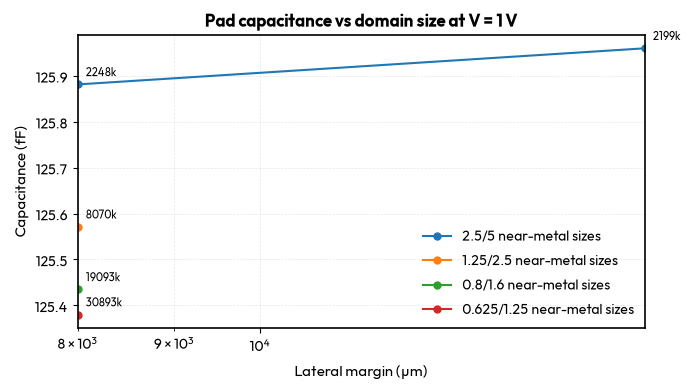


Lateral margin at the 2.5/5 near-metal sizes, 1600 µm of substrate, 1600 µm of air
      margin   elements   C11 (fF)      dC11   dC11 %
        8000    2248486   125.8811                   
       16000    2199348   125.9598   +0.0787   +0.06%

Lateral margin at the 1.25/2.5 near-metal sizes, 1600 µm of substrate, 1600 µm of air
      margin   elements   C11 (fF)      dC11   dC11 %
        8000    8070500   125.5709                   

Lateral margin at the 0.8/1.6 near-metal sizes, 1600 µm of substrate, 1600 µm of air
      margin   elements   C11 (fF)      dC11   dC11 %
        8000   19093439   125.4345                   

Lateral margin at the 0.625/1.25 near-metal sizes, 1600 µm of substrate, 1600 µm of air
      margin   elements   C11 (fF)      dC11   dC11 %
        8000   30893436   125.3797                   

Near-metal size at margin 8000 µm, 1600 µm of substrate, 200 µm of air
  near-metal   elements   C11 (fF)      dC11   dC11 %
        5/10     701273   125.8807        

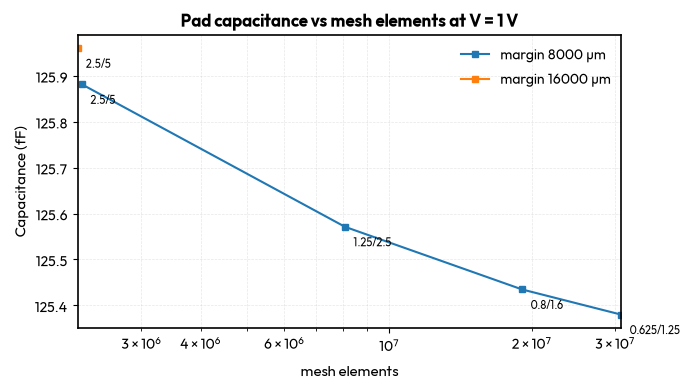


Air at margin 8000 µm, 1600 µm of substrate, 1.25/2.5 near-metal sizes
         air   elements   C11 (fF)      dC11   dC11 %
         200    8252792   124.8061                   
        1600    8070500   125.5709   +0.7648   +0.61%

Air at margin 8000 µm, 1600 µm of substrate, 2.5/5 near-metal sizes
         air   elements   C11 (fF)      dC11   dC11 %
         200    2275321   125.1573                   
         400    2216655   125.7735   +0.6162   +0.49%
         800    2204951   125.8778   +0.1044   +0.08%
        1600    2248486   125.8811   +0.0033   +0.00%
        3200    2255784   125.8820   +0.0009   +0.00%

Air at margin 16000 µm, 1600 µm of substrate, 2.5/5 near-metal sizes
         air   elements   C11 (fF)      dC11   dC11 %
         200    2521782   125.1633                   
        1600    2199348   125.9598   +0.7965   +0.64%

Substrate at margin 8000 µm, 200 µm of air, 2.5/5 near-metal sizes
   substrate   elements   C11 (fF)      dC11   dC11 %
        1600    227

In [12]:
def compact_element_count(count: int) -> str:
    """Format an element count for a plot label.

    Args:
        count: Number of mesh elements.

    Returns:
        The count in thousands, or the plain count below ten thousand.
    """
    return f"{count / 1e3:.0f}k" if count >= 10_000 else f"{count:,}"


def domain_near_metal_name(row: dict[str, Any]) -> str:
    """Return the near-metal setting a row was solved at.

    The two pinned conductor sizes identify the setting, so a row written by an
    earlier run is still read as the setting it was solved with, whatever name
    that run recorded.

    Args:
        row: One row read from the domain JSON.

    Returns:
        The setting name, or the pad and ground sizes spelled out when they match
        no entry of ``NEAR_METAL_SIZES``.
    """
    for candidate, (pad_hmax_um, _, ground_hmax_um, _) in NEAR_METAL_SIZES.items():
        if (
            row.get("pad_hmax_um") == pad_hmax_um
            and row.get("ground_hmax_um") == ground_hmax_um
        ):
            return candidate
    if (name := row.get("near_metal")) is not None:
        return str(name)
    return f"pad {row.get('pad_hmax_um')}/gnd {row.get('ground_hmax_um')} µm near-metal"


def ordered_near_metal_names(names: set[str]) -> list[str]:
    """Sort near-metal setting names into refinement order.

    Args:
        names: Setting names present in the rows being read.

    Returns:
        The names ``NEAR_METAL_SIZES`` holds, in its order, then any name it does
        not know.
    """
    known = [name for name in NEAR_METAL_SIZES if name in names]
    return known + sorted(names.difference(NEAR_METAL_SIZES))


def print_domain_table(
    title: str, header: str, points: list[tuple[str, int, float]]
) -> None:
    """Print one comparison with each row's step from the row above it.

    Args:
        title: Line describing the comparison, printed above the table.
        header: Column heading for the varying parameter.
        points: One ``(value, element count, capacitance in fF)`` per row.
    """
    print(f"\n{title}")
    print(f"{header:>12} {'elements':>10} {'C11 (fF)':>10} {'dC11':>9} {'dC11 %':>8}")
    for index, (value, element_count, capacitance_ff) in enumerate(points):
        step = change = ""
        if index > 0:
            previous_ff = points[index - 1][2]
            step = f"{capacitance_ff - previous_ff:>+9.4f}"
            change = f"{(capacitance_ff - previous_ff) / previous_ff:>+8.2%}"
        print(
            f"{value:>12} {element_count:>10} {capacitance_ff:>10.4f} "
            f"{step:>9} {change:>8}"
        )


domain_file = result_file(DOMAIN_JSON)

if domain_file is None:
    explain_missing_results(DOMAIN_JSON)
else:
    domain_payload = json.loads(domain_file.read_text())
    domain_rows = (
        domain_payload
        if isinstance(domain_payload, list)
        else domain_payload.get("rows") or []
    )
    if isinstance(domain_payload, dict):
        for failure in domain_payload.get("failures") or []:
            print(f"{failure['label']} failed: {failure['error']}")

    if not domain_rows:
        explain_missing_results(DOMAIN_JSON)
        print("The file on disk carries no rows.")
    else:
        voltages_v = {float(row["voltage_v"]) for row in domain_rows}
        if len(voltages_v) != 1:
            raise ValueError("Domain rows have different solved voltages")
        solved_voltage_v = voltages_v.pop()

        base_rows = [
            row
            for row in domain_rows
            if math.isclose(float(row["air_height_um"]), AIR_HEIGHT_UM)
            and math.isclose(
                float(row["substrate_thickness_um"]), SUBSTRATE_THICKNESS_UM
            )
        ]
        settings = ordered_near_metal_names({
            domain_near_metal_name(row) for row in base_rows
        })
        if not base_rows:
            print(
                f"No rows at {SUBSTRATE_THICKNESS_UM:g} µm of substrate and "
                f"{AIR_HEIGHT_UM:g} µm of air are on disk."
            )

        # The effects as numbers: how far C11 moves with the lateral margin at a
        # fixed mesh, and how far it moves from one near-metal setting to the next
        # smaller one at a fixed domain.
        spreads_ff = {
            setting: float(
                np.ptp([
                    float(row["c11_f"]) * 1e15
                    for row in base_rows
                    if domain_near_metal_name(row) == setting
                ])
            )
            for setting in settings
        }

        # Every near-metal setting solved at each margin, substrate, and air
        # height, so a table can be printed per group in refinement order.
        mesh_groups: dict[tuple[float, float, float], list[dict[str, Any]]] = {}
        for row in domain_rows:
            group = (
                float(row["lateral_margin_um"]),
                float(row["substrate_thickness_um"]),
                float(row["air_height_um"]),
            )
            mesh_groups.setdefault(group, []).append(row)
        near_metal_steps_ff: list[float] = []

        fig, ax = plt.subplots(figsize=(7, 4))
        for setting in settings:
            series = sorted(
                (row for row in base_rows if domain_near_metal_name(row) == setting),
                key=itemgetter("lateral_margin_um"),
            )
            margins_um = np.array(
                [row["lateral_margin_um"] for row in series], dtype=float
            )
            capacitance_ff = (
                np.array([row["c11_f"] for row in series], dtype=float) * 1e15
            )
            ax.plot(
                margins_um,
                capacitance_ff,
                marker="o",
                markersize=5,
                label=f"{setting} near-metal sizes",
            )
            for margin, value, row in zip(
                margins_um, capacitance_ff, series, strict=True
            ):
                ax.annotate(
                    compact_element_count(int(row["element_count"])),
                    (margin, value),
                    textcoords="offset points",
                    xytext=(6, 6),
                    fontsize=8,
                )
        if base_rows:
            ax.set_xscale("log")
            ax.set_xlabel("Lateral margin (µm)")
            ax.set_ylabel("Capacitance (fF)")
            ax.set_title(
                f"Pad capacitance vs domain size at V = {solved_voltage_v:g} V"
            )
            ax.grid(True, which="both", alpha=0.3)
            ax.legend()
            plt.tight_layout()
            plt.show()

        for setting in settings:
            print_domain_table(
                f"Lateral margin at the {setting} near-metal sizes, "
                f"{SUBSTRATE_THICKNESS_UM:g} µm of substrate, "
                f"{AIR_HEIGHT_UM:g} µm of air",
                "margin",
                [
                    (
                        f"{row['lateral_margin_um']:g}",
                        int(row["element_count"]),
                        float(row["c11_f"]) * 1e15,
                    )
                    for row in sorted(
                        (
                            row
                            for row in base_rows
                            if domain_near_metal_name(row) == setting
                        ),
                        key=itemgetter("lateral_margin_um"),
                    )
                ],
            )

        # One table per group of rows sharing a margin, a substrate, and an air
        # height, so each table is one near-metal series in refinement order.
        for group_key, group in sorted(mesh_groups.items()):
            margin, substrate_um, air_um = group_key
            by_setting = {domain_near_metal_name(row): row for row in group}
            ordered = [
                by_setting[name] for name in ordered_near_metal_names(set(by_setting))
            ]
            if len(ordered) < 2:
                continue
            print_domain_table(
                f"Near-metal size at margin {margin:g} µm, {substrate_um:g} µm of "
                f"substrate, {air_um:g} µm of air",
                "near-metal",
                [
                    (
                        domain_near_metal_name(row),
                        int(row["element_count"]),
                        float(row["c11_f"]) * 1e15,
                    )
                    for row in ordered
                ],
            )
            near_metal_steps_ff.extend(
                float(later["c11_f"]) * 1e15 - float(earlier["c11_f"]) * 1e15
                for earlier, later in pairwise(ordered)
            )

        if spreads_ff and near_metal_steps_ff:
            largest_spread = max(spreads_ff.values())
            largest_step = max(abs(step) for step in near_metal_steps_ff)
            print(
                f"\nLargest spread across the margins at a fixed mesh: "
                f"{largest_spread:.4f} fF"
            )
            print(
                f"Largest step between neighbouring near-metal settings: "
                f"{largest_step:.4f} fF"
            )
            if largest_step > largest_spread:
                print(
                    "The near-metal size moves C11 more than the lateral walls do "
                    "in these rows, so the mesh is the stronger limiter of the two, "
                    "and neither has stopped moving it."
                )
            else:
                print(
                    "The lateral spread is at least as large as the near-metal step "
                    "in these rows; read the two together before calling either "
                    "settled."
                )

        fig, ax = plt.subplots(figsize=(7, 4))
        for margin in sorted({float(row["lateral_margin_um"]) for row in base_rows}):
            series = sorted(
                (
                    row
                    for row in base_rows
                    if math.isclose(float(row["lateral_margin_um"]), margin)
                ),
                key=itemgetter("element_count"),
            )
            element_counts = np.array(
                [row["element_count"] for row in series], dtype=float
            )
            capacitance_ff = (
                np.array([row["c11_f"] for row in series], dtype=float) * 1e15
            )
            ax.plot(
                element_counts,
                capacitance_ff,
                marker="s",
                markersize=5,
                label=f"margin {margin:g} µm",
            )
            for count, value, row in zip(
                element_counts, capacitance_ff, series, strict=True
            ):
                ax.annotate(
                    domain_near_metal_name(row),
                    (count, value),
                    textcoords="offset points",
                    xytext=(6, -14),
                    fontsize=8,
                )
        if base_rows:
            ax.set_xscale("log")
            ax.set_xlabel("mesh elements")
            ax.set_ylabel("Capacitance (fF)")
            ax.set_title(
                f"Pad capacitance vs mesh elements at V = {solved_voltage_v:g} V"
            )
            ax.grid(True, which="both", alpha=0.3)
            ax.legend()
            plt.tight_layout()
            plt.show()

        # The two vertical lengths get the same treatment: a series is the set of
        # rows that hold the other length, the margin, and the near-metal setting
        # fixed, so only the swept length moves within a table. The sweep does not
        # have to start at the base case; each series prints the value of the
        # length it holds, so a pair solved off the base case is still read.
        variation_tables = 0
        for value_key, fixed_key, fixed_name, header in (
            ("air_height_um", "substrate_thickness_um", "substrate", "air"),
            ("substrate_thickness_um", "air_height_um", "air", "substrate"),
        ):
            series: dict[tuple[float, float, str], dict[float, dict[str, Any]]] = {}
            for row in domain_rows:
                series.setdefault(
                    (
                        float(row[fixed_key]),
                        float(row["lateral_margin_um"]),
                        domain_near_metal_name(row),
                    ),
                    {},
                ).setdefault(float(row[value_key]), row)
            for (fixed_value, margin, setting), group in sorted(series.items()):
                if len(group) < 2:
                    continue
                variation_tables += 1
                print_domain_table(
                    f"{header.capitalize()} at margin {margin:g} µm, "
                    f"{fixed_value:g} µm of {fixed_name}, "
                    f"{setting} near-metal sizes",
                    header,
                    [
                        (
                            f"{value:g}",
                            int(row["element_count"]),
                            float(row["c11_f"]) * 1e15,
                        )
                        for value, row in sorted(group.items())
                    ],
                )
        if not variation_tables:
            print(
                "\nNo series holds the other vertical length, the margin, and the "
                "near-metal setting fixed while moving the air height or the "
                "substrate thickness on the rows on disk, so that comparison is "
                "skipped."
            )

        print(
            "\nA shift read off a mesh that is still moving is not a converged "
            "shift, in the box or in the metal. C11 here is a one-terminal "
            "capacitance, not the two-pad charging capacitance."
        )

The series is read by the shape of the curves and by the size of the steps
printed next to them. A margin curve that flattens says the outer walls no
longer set $C_{11}$; a near-metal table whose steps shrink towards the finest
setting says the element size no longer does; an air or substrate series whose
steps shrink with the taller or thicker box says the same of the box.

At the chosen 8000 µm / 1600 µm / 1600 µm box the near-metal ladder flattens:
the last step, from `0.8/1.6` to `0.625/1.25` at 8000 µm of margin, moves
$C_{11}$ by -0.0548020655 fF, which is -0.0437%. The one-terminal capacitance
is therefore stable to about 0.05% over that one refinement. That is an
empirical last-step metric and not a rigorous error bound: it says the value
barely moved between those two meshes, not how far it still sits from the
mesh-independent answer. The box levers are read from their own tables, where
the tallest air column tested, 1600 µm to 3200 µm at the `2.5/5` setting, moves
$C_{11}$ by +0.000856 fF.

The box cannot be reduced to its lateral walls alone: the air above the metal is
a lever the margin series does not move, so it is read from its own table. The
box stays finite and the ground plane is still the prepared layout's own, so the
outer walls act on $C_{11}$ at any mesh. The number is a one-terminal
capacitance rather than the two-pad charging capacitance.

## Summary

1. Built a QPDK `double_pad_transmon_with_bbox` cell and made an EM-only copy
   with `JJ_AREA`/`JJ_PATCH` removed, so the SQUID and its leads are not in the
   solved geometry.
2. Extracted the two pad polygons and the ground plane with
   `prepare_comsol_layout(..., feed_ports=None)`.
3. Built the COMSOL sheet model and added an Electrostatics study: a voltage
   terminal on the left pad, ground on the right pad and the ground plane, a
   mesh, and a stationary study.
4. Ran the main solve on 8000 µm of lateral margin, 1600 µm of silicon, and
   1600 µm of air with the element sizes pinned to absolute values, exported
   `es.C11` and `es.intWe`, checked them against each other through
   $2 W_e / V^2$, and replotted the exported field map. The saved metrics carry
   the settings the solve used.
5. Added one series that pins the element sizes to absolute values and moves the
   lateral margin, the near-metal setting, the air height, and the substrate
   thickness around a base case, at a mesh that no longer follows the domain. It
   answers the box question a mesh study cannot, and shows by how much the
   near-metal mesh and the box move $C_{11}$. The finest step at the chosen box
   is -0.0437%, so the one-terminal value is stable to about 0.05% over the last
   tested refinement.

### Limitations

- The solve is electrostatic; the metal is a perfect conductor and there is no
  Josephson inductance, so no resonance is solved.
- The `f_LC` number uses a chosen $L_J$ and $C_{11}$ in place of a two-pad
  differential capacitance. It is not a transmon eigenfrequency or $f_{01}$.
- The EM-only copy omits the SQUID loop and its leads, so their parasitic
  capacitance is missing from $C_{11}$.
- The ~0.05% stability is an empirical last-step metric, not a rigorous error
  bound. It compares two meshes, so a further refinement of the metal could
  still move $C_{11}$.
- The differential transmon capacitance is a separate question: $C_{11}$ is the
  driven pad's capacitance to the grounded rest of the chip, not the
  differential-mode capacitance of the two pads.
- The field at the pad edges is singular, so the peak $|\mathbf{E}|$ in the map
  stays mesh-limited even where the capacitance has settled.
- The main capacitance and field map use one mesh setting; the saved
  convergence plots are from separate solves.
- The domain is finite: the outer walls are a zero-charge truncation and the
  ground plane is the prepared layout's own box, so $C_{11}$ carries their
  effect at any mesh.

### Next steps

- Refine the near-metal mesh once more below `0.625/1.25`, or grow the box, to
  test whether the last-step figure holds.
- Extract the two-pad capacitance matrix, then use its differential-mode
  capacitance with a junction model in the QPDK Hamiltonian workflow
  ({doc}`/notebooks/scqubits_parameter_calculation`).

## References

```{bibliography}
:filter: docname in docnames
```